From the paper we can see that there are the second and fourth order scaling currents. These 'formulae' are given below. 

$\frac{\theta-\theta_{0}}{\theta_{r}}=-\left(\frac{I_{dc}}{I_{*,2}}\right)^{2}$

$I_{*,2}\ =\ I_{dc}\cdot\left(-\frac{\theta-\theta_{0}}{\theta_{r}}\right)^{-\frac{1}{2}}$

$\frac{\theta-\theta_{0}}{\theta_{r}}=-\left(\frac{I_{dc}}{I_{*,4}}\right)^{2}-\left(\frac{I_{dc}}{I_{*,4}}\right)^{4}$

$I_{*,4}\ =\ I_{dc}\cdot\left(-\frac{\theta-\theta_{0}}{\theta_{r}}-1\right)^{-\frac{1}{2}}$

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import scienceplots
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator, RegularGridInterpolator
from scipy.optimize import differential_evolution
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import h5py
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.fft import fft, fftfreq, fftshift, ifft, ifftshift
import math
from scipy import integrate
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from whittaker_eilers import WhittakerSmoother
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.interpolate import LinearNDInterpolator
from mpl_toolkits.mplot3d import Axes3D
import os
from PIL import Image, ImageSequence
from scipy.spatial import cKDTree
from itertools import product
from numpy import load

plt.style.use(["science", "no-latex", "grid"])
plt.rcParams.update({'font.size': 12})
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{siunitx}"
plt.rcParams["figure.figsize"] = (14, 7) 

In [3]:
## Extracting the 'bias current dependent' phase data
file = h5py.File('istar_data/s1/00254_S21_1to5_0dBatten_broadscan_pumpon_11p85_n5dBmUPH_9.015e-08_edelay_1.25V_11.85GHz_-5_dBm_pump.hdf5', 'r')
freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

freqs = np.linspace(freq_start, freq_stop, probe_pts)
phase = np.asarray(file['sweep_dataframe']).flatten() 

## Extracting the 'zero bias probe tone' phase data
file_naught = h5py.File('istar_data/00204_S21_1to5_0dBatten_broadscan_pumpon_11p85_n5dBmUPH_9.015e-08_edelay_0.0V_11.85GHz_-5_dBm_pump.hdf5', 'r')
freq_start = file_naught['Parameters']['VNA_PARAMETERS']['freq_start'][0]
freq_stop = file_naught['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
probe_pts = file_naught['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

freqs_naught = np.linspace(freq_start, freq_stop, probe_pts)
phase_naught = np.asarray(file_naught['sweep_dataframe']).flatten() 

## Extracting the 'full light traversal time' 
twpa_length = 0.1575                ## length of the twpa in m
tau = twpa_length/(0.8*3*10**8)     ## transversal time assuming that the speed of light inside the twpa is 0.8c

## Extracting the 'relative phase'
def phase_rel(w, t=tau):
    return (w*t)/2

def istar_second(theta, theta_naught, theta_r, I_dc):
    return (I_dc * (-((theta - theta_naught)/(theta_r)))**(-1/2))

def istar_fourth(theta, theta_naught, theta_r, I_dc):
    return (I_dc * (((-((theta - theta_naught)/(theta_r))) - 1)**(-1/2)))

istars2 = []
istars4 = []
for i in range(0, len(freqs)):
    istars2.append(istar_second(phase[i], phase_naught[i], phase_rel(freqs[i]), 1.25))
    istars4.append(istar_fourth(phase[i], phase_naught[i], phase_rel(freqs[i]), 1.25))
    
freqs

C:\Users\rishi\AppData\Local\Temp\ipykernel_8204\1485423519.py:28: RuntimeWarning: invalid value encountered in scalar power
  return (I_dc * (-((theta - theta_naught)/(theta_r)))**(-1/2))
C:\Users\rishi\AppData\Local\Temp\ipykernel_8204\1485423519.py:31: RuntimeWarning: invalid value encountered in scalar power
  return (I_dc * (((-((theta - theta_naught)/(theta_r))) - 1)**(-1/2)))


array([4.00000000e+09, 4.00142857e+09, 4.00285714e+09, ...,
       1.39971429e+10, 1.39985714e+10, 1.40000000e+10], shape=(7001,))

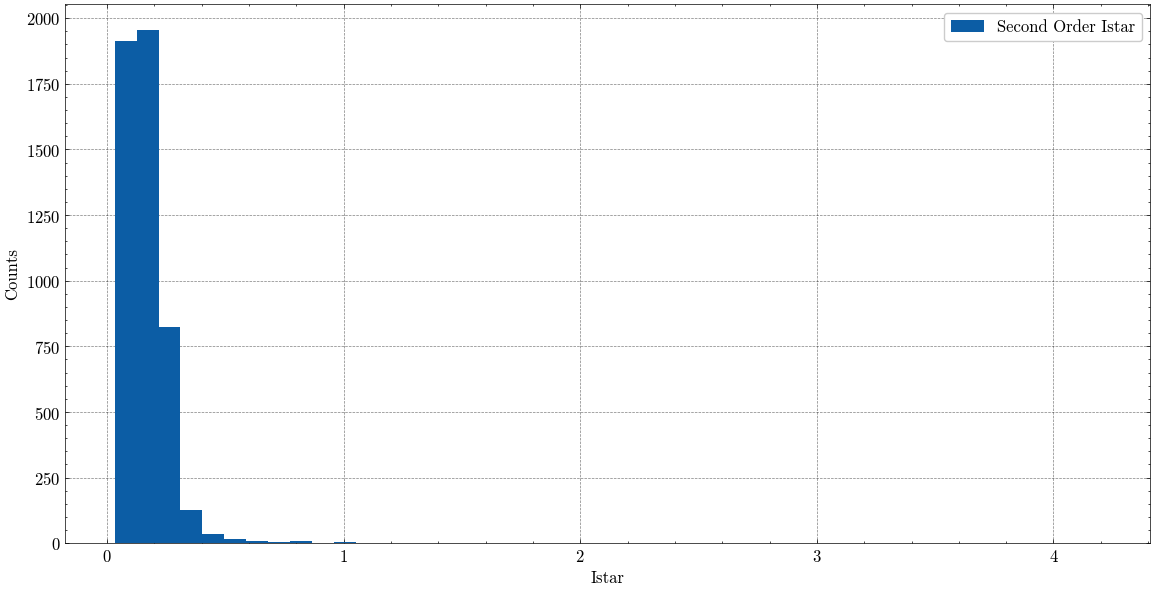

In [4]:
istars2 = np.array(istars2)
istars4 = np.array(istars4)

plt.hist(istars2, bins=45, label='Second Order Istar')
# plt.hist(istars4, bins=25, label='Fourth Order Istar')
plt.xlabel('Istar')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [5]:
twpa_length = 0.1575                ## length of the twpa in m
tau = twpa_length/(0.6*3*10**8)     ## transversal time assuming that the speed of light inside the twpa is 0.8c

def phase_rel(f, t=tau):
    return (2*np.pi*f*t)

def istar_second(theta, theta_naught, theta_r, I_dc):
    return (I_dc * (-((theta - theta_naught)/(theta_r)))**(-1/2))

def calculate_istar(file_dep, file_zero, frequency):
    ## Original bias-current dependent file
    file = h5py.File(file_dep, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    phase = np.asarray(file['sweep_dataframe']).flatten() 
    
    params_txt = (file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]).decode("utf-8")

    for i in params_txt.split("_"):
        if i.endswith('V'):
            bias_current = float(i[0:i.find('V')])
    
    ## Zero bias-current file 
    file_naught = h5py.File(file_zero, 'r')
    # freq_start = file_naught['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    # freq_stop = file_naught['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    # probe_pts = file_naught['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    # freqs_naught = np.linspace(freq_start, freq_stop, probe_pts)
    phase_naught = np.asarray(file_naught['sweep_dataframe']).flatten() 
    
    phase = phase * (np.pi/180)
    phase_naught = phase_naught * (np.pi/180)

    ## Calculating Istar
    
    istars = []
    for i in range(0, len(freqs)):
        istars.append(istar_second(phase[i], phase_naught[i], phase_rel(freqs[i]), bias_current))
        
    istars = np.array(istars)

    indices = np.where(freqs >= frequency)
    index = indices[0][0]
    return [bias_current, istars[index]]
        
    # mask = np.isfinite(istars)
    # istars = istars[mask]

    # return [bias_current, np.mean(istars)]

def plot_istars(folder_name, file_zero_bias, frequency):
    bias_currents = []
    istars = []
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.hdf5"):
        bias_current, istar = calculate_istar(f, file_zero_bias, frequency)
        bias_currents.append(bias_current)
        istars.append(istar)
        
    return [bias_currents, istars]
    
    # plt.plot(bias_currents, istars, 'o')
    # plt.plot(bias_currents, istars)
    # plt.xlabel("Bias Current (mA)")
    # plt.ylabel("Istar (mA)")
    # plt.title("Bias Current vs Scaling Current")
    # plt.show()
    
def plot_istars_freqs(start_freq, stop_freq, freq_step):
    for i in range(0, int((stop_freq-start_freq)/freq_step) + 1):
        bias_currents, istars = plot_istars("istar_data/s1", 
                    "istar_data/00204_S21_1to5_0dBatten_broadscan_pumpon_11p85_n5dBmUPH_9.015e-08_edelay_0.0V_11.85GHz_-5_dBm_pump.hdf5", 
                    start_freq + i*freq_step)
        plt.plot(bias_currents, istars, 'ro', markersize=2)
        plt.plot(bias_currents, istars, label=('Frequency: ' + str(start_freq + i*freq_step)) + ' Hz')
        plt.xlabel('Bias Current (mA)')
        plt.ylabel('Scaling Current (mA)')
    plt.legend()

C:\Users\rishi\AppData\Local\Temp\ipykernel_7812\1272994354.py:8: RuntimeWarning: invalid value encountered in scalar power
  return (I_dc * (-((theta - theta_naught)/(theta_r)))**(-1/2))


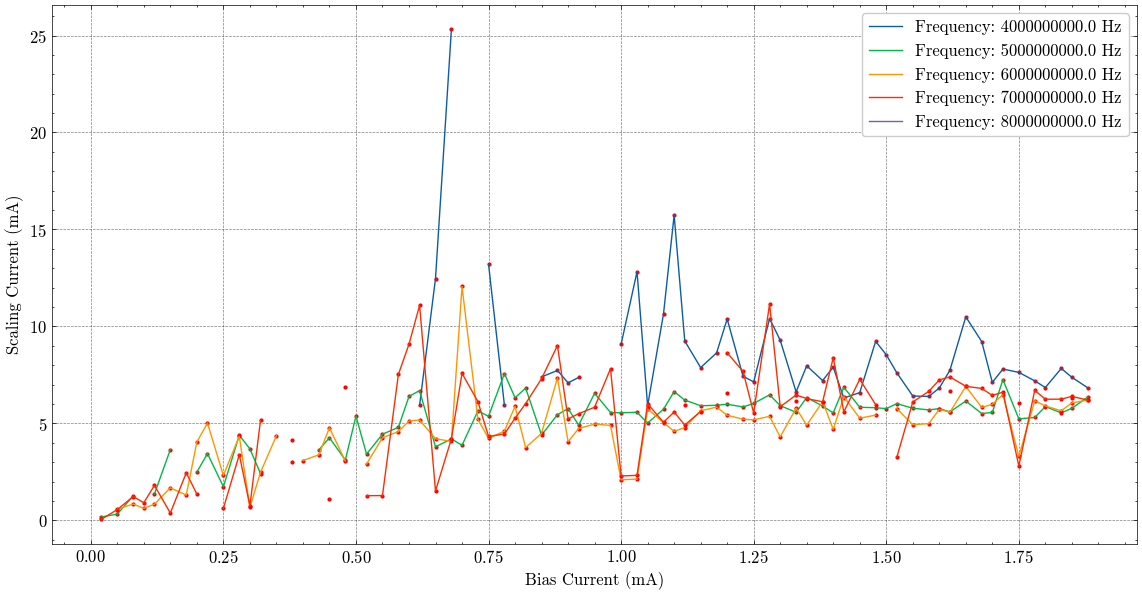

In [5]:
plot_istars_freqs(4e9, 8e9, 1e9)

From Milad's paper from Mantegazzini et al., they get $I_{*}$ in a different sort of way than what I've encountered previously. Using the following formula they do a linear fit between $\Delta\theta$ and $I_{dc}^2$ to find the parameter for $I_{*}$

$\frac{\Delta\theta}{\theta_{0}}=\frac{1}{2}\left(\frac{I_{dc}}{I_{*}}\right)^{2}$

Here they define $\theta_{0}$ as $\theta_{0}\approx N_{sc}\cdot\pi$ where Milad told me that $N_{sc}=320$ for us. 

I think either way you can only get an $I_{*}$ measurement (one value) if you're at a certain frequency, otherwise you'd get a range of $I_{*}$ values again. 

So do to a linear fit, we have to get it in a form of which a line can be fit to this data at a certain frequency that we wish to look at. 

$2\frac{\Delta\theta}{\theta_{0}}=\frac{1}{\left(I_{*}\right)^{2}}\left(I_{dc}\right)^{2}$

Here we can see the left-hand side is the 'y' data and the independent variable will be the square of the dc bias current with the slop of our graph help to provide us the 'scaling' current $I_{*}$ by doing the following: 

$I_{*}=\sqrt{\frac{1}{m}}$

, where $m$ is the slope of our graph. 


Okay so basically all of what I said is mostly like a lie so do not do this:

In [4]:
def linear_fit(x, m):
    return x*m

def m_to_istar(m):
    return np.sqrt(1/m)

def istar_relation(phase_file, Nsc, frequency_band):
    file = h5py.File(phase_file, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    phase = np.asarray(file['sweep_dataframe']).flatten() 
    phase = phase * (np.pi/180)    
    
    params_txt = (file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]).decode("utf-8")

    for i in params_txt.split("_"):
        if i.endswith('V'):
            bias_current = float(i[0:i.find('V')])
            
    phase_naught = Nsc * np.pi
    delta_theta = (phase)/phase_naught  
    
    indices = np.where(freqs >= frequency_band)
    index = indices[0][0]
    
    x = bias_current**2
    y = 2 * (delta_theta[index])
    return [x, y]
    
def mantegazzini_istar(folder_name, frequency_band):
    squared_dc_currents = []
    delta_thetas = []
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.hdf5"):
        bias_current, istar = istar_relation(f, 320, frequency_band)
        squared_dc_currents.append(bias_current)
        delta_thetas.append(istar)
        
    param, cov = curve_fit(linear_fit, squared_dc_currents, delta_thetas)
    perr = np.sqrt(np.diag(cov))
    m_fit = param
    m_fit_error = perr
    
    fitted_y = linear_fit(squared_dc_currents, m_fit)
    
    plt.plot(squared_dc_currents, delta_thetas, 'o', label='Raw Data')
    plt.plot(squared_dc_currents, fitted_y, label='Linear Fit')
    plt.plot()
    plt.xlabel(r'$(I_{dc})^2$')
    plt.ylabel(r'$\frac{2\Delta\theta}{\theta_0}$')
    plt.legend()
    plt.show()
    
    return [m_to_istar(m_fit), m_to_istar(m_fit_error)]   

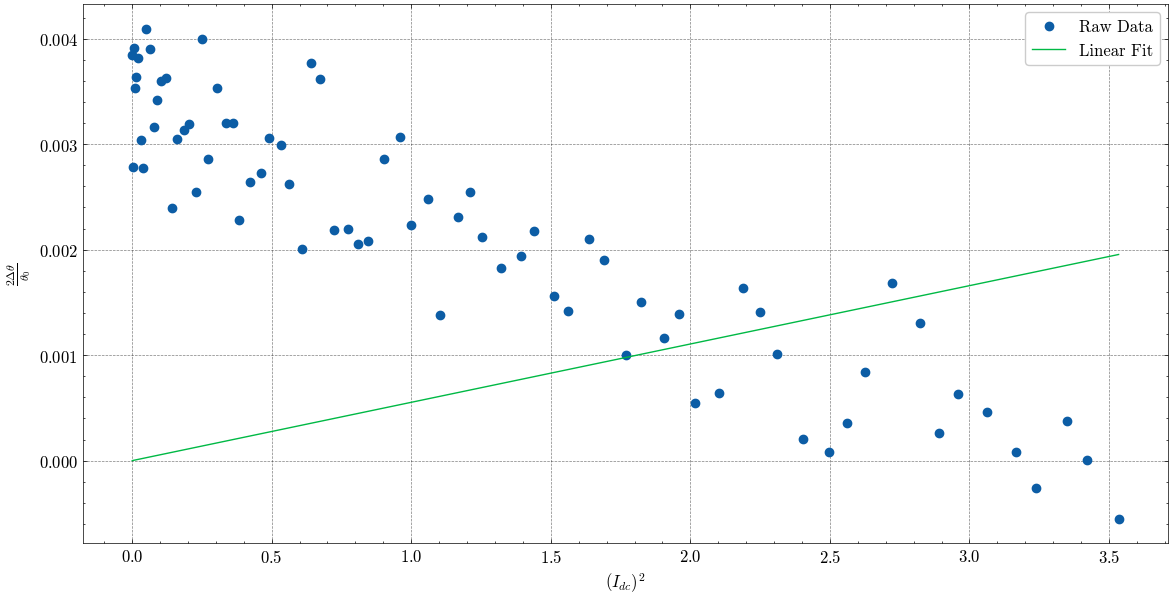

[array([42.52633737]), array([77.21779012])]

In [7]:
mantegazzini_istar("istar_data/s1", 4e9)

Okay so basically this is the relation that we should be looking for when trying to fit for $I_{*}$: 

$\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}=-\frac{1}{2}\left(\frac{I}{I_{*}}\right)^{2}$

$\left(-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}\right)=\frac{1}{\left(I_{*}\right)^{2}}\cdot\left(\left(I_{dc}\right)^{2}\right)$

$\left(-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}\right)=\frac{1}{\left(I_{*}\right)^{2}}\cdot\left(I_{dc}\right)^{2}$

Where in this expression we can basically get a linear fit to get the parameter for $I_{*}$. One thing to note is that $\theta_{r}=2\pi f\Delta t_{TWPA}$, where $\Delta t_{TWPA}$ is the time of flight of the TWPA which can be obtained from the TDR measurement. However, since I'm not fully trusting the TDR measurements at this point in time, another way to approach this is through the dispersion relations. We have expressions for the phase velocity which can be related back to the time of flight parameter as follows. 

$v_{p}=\frac{N_{sc}L_{sc}}{\Delta t_{TWPA}}=\lambda_{sb}f_{sb}=\frac{\omega}{k\left(\omega\right)}=2L_{sc}f_{sb}$

These are all the expressions for the phase velocity that we can use. Since we have the dispersion plot of the angular frequency ($\omega$) versus the k vector, we can calculate this phase velocity. We can also do cross-checks because we have what $L_{sc}$ and $N_{sc}$, which are $35 * 15 \mu m$ and $320$ respectively. 

Step 1: Calculate an array of the phase velocity, $v_p$ using the dispersion relation for different $\omega$. 

Step 2: Use this phase velocity to solve for an array of time of flights, $\Delta t_{TWPA}$ using also the length and number of cells. 

Step 3: For a certain frequency, we want to use the bias current dependent phases, zero-bias phases, and the relative phase, $\theta(I)$, $\theta_0$, $\theta_r$ respectively as well as the bias currents to create a scatter plot that resembles the first expression. 

Step 4: We perform a linear fit on the data to get a fit for essentially the slope of this graph which can be used to calculate $I_{*}$.

In [ ]:
## Important Values
N_sc = 320.0
L_sc = (35.0*15.0)/10**6

def linear_fit(x, m):
    return x*m

def quadratic_fit(x, a):
    return a*x**2

## Step 1: Phase Velocity 

data = load('istar_data/k.npz')
lst = data.files

frequency_twpa = data[lst[0]]
k_vector = data[lst[1]]/L_sc  ## rad/cell / m/cell = rad/m

omega = 2*np.pi*frequency_twpa*1e9 ## rad/s

# plt.plot(k_vector, omega)
# plt.xlabel('Wave Vector, k (rads/cell*m??)')
# plt.ylabel(r'$\omega$' + ' (rads/s)')
# plt.title('Dispersion Plot for TWPA')
# plt.show()

phase_velocity = (omega/k_vector) ## rad/s / rad/m = m/s
# plt.plot(frequency, phase_velocity)
# plt.show()
## m/s??? When plotting this the phase velocity speeds do not make sense to me, why are they above the speed of light c?

## Step 2: Time of Flight
tau_twpa = (N_sc*L_sc)/phase_velocity ## s?? When plotting this it seems to be in the 100s of ns which doesn't really make sense to me? Feels like too long
# plt.plot(frequency, tau_twpa)
# plt.plot()

def tau_twpa_diff(N_sc, f_sb):
    return N_sc/(2*f_sb)

## Okay after using the value for the phase velocity that was obtained in the DARTWARS paper, I ran that through the length of our TWPA to get a ballpark estimate for the 
## time that it takes for the light to get across and it seems to be in the hundreds of nanoseconds? So I feel a little bit better but yeah, speed of light still ifffy

## Step 3: Istar Expression
def istar_expression(file_dep, file_zero, frequency_band, twpa_times_freqs, twpa_times):
    ## Original bias-current dependent file
    file = h5py.File(file_dep, 'r')
    freq_start = file['Parameters']['VNA_PARAMETERS']['freq_start'][0]
    freq_stop = file['Parameters']['VNA_PARAMETERS']['freq_stop'][0]
    probe_pts = file['Parameters']['VNA_PARAMETERS']['probe_pts'][()]

    freqs = np.linspace(freq_start, freq_stop, probe_pts)
    phase = np.asarray(file['sweep_dataframe']).flatten() 
        
    params_txt = (file['Parameters']['PHYSICAL_PARAMETERS']['Description'][()]).decode("utf-8")

    for i in params_txt.split("_"):
        if i.endswith('V'):
            bias_current = float(i[0:i.find('V')])
    
    ## Zero bias-current file 
    file_naught = h5py.File(file_zero, 'r')
    phase_naught = np.asarray(file_naught['sweep_dataframe']).flatten() 
    
    phase = phase * (np.pi/180)
    phase_naught = phase_naught * (np.pi/180)
    
    ## Relative phase
    indices_phase = np.where(freqs >= frequency_band)
    indices_twpa = np.where(twpa_times_freqs*1e9 >= frequency_band)
    index_phase = indices_phase[0][0]
    index_twpa = indices_twpa[0][0]
    
    theta_I = phase[index_phase]
    theta_0 = phase_naught[index_phase]
    theta_r = 2*np.pi*frequency_band*twpa_times[index_twpa]
    
    ## Expression buildup 
    x = bias_current
    y = -2*((theta_I-theta_0)/(theta_r))
    
    return [x, y]

def calculating_istar(folder_name, frequency_band):
    dc_currents = []
    delta_thetas = []
    
    folder_path = Path(folder_name)
    for f in folder_path.glob("*.hdf5"):
        x, y = istar_expression(f,
                                "istar_data/00082_S21_1to5_0dBatten_broadscanUPH_9.015e-08_edelay_0.0V_0.0GHz_-100_dBm_pump.hdf5", 
                                frequency_band, 
                                frequency_twpa, 
                                tau_twpa)
        dc_currents.append(x)
        delta_thetas.append(y)
        
    dc_currents = np.array(dc_currents)
    delta_thetas = np.array(delta_thetas)
            
    param, cov = curve_fit(quadratic_fit, dc_currents, delta_thetas)
    perr = np.sqrt(np.diag(cov))
    m_fit = param
    m_fit_error = perr
    
    fitted_y = quadratic_fit(dc_currents, m_fit)
    
    # plt.plot(dc_currents, delta_thetas, 'o', label='Raw Data')
    # plt.plot(dc_currents, fitted_y, label='Linear Fit')
    # plt.xlabel(r'$I_{dc}$' + " (mA)")
    # plt.ylabel(r'$-2\frac{\theta\left(I\right)-\theta_{0}}{\theta_{r}}$')
    # plt.legend()
    # plt.show()
    
    return [m_to_istar(m_fit), m_to_istar(m_fit_error)] 

C:\Users\rishi\AppData\Local\Temp\ipykernel_28292\3874509288.py:27: RuntimeWarning: invalid value encountered in divide
  phase_velocity = (omega/k_vector) ## rad/s / rad/m = m/s


In [9]:
calculating_istar("istar_data/s2", 4e9)[1][0]

np.float64(21.170611685508362)

In [16]:
istar_frequencies = np.linspace(4e9, 14e9, 150)
istars = []
istars_err = []

for i in istar_frequencies:
    istars.append(calculating_istar("istar_data/s2", i)[0][0])
    istars_err.append(calculating_istar("istar_data/s2", i)[1][0])
    
istars = np.array(istars)    
istars_err = np.array(istars_err)

In [ ]:
istars_err

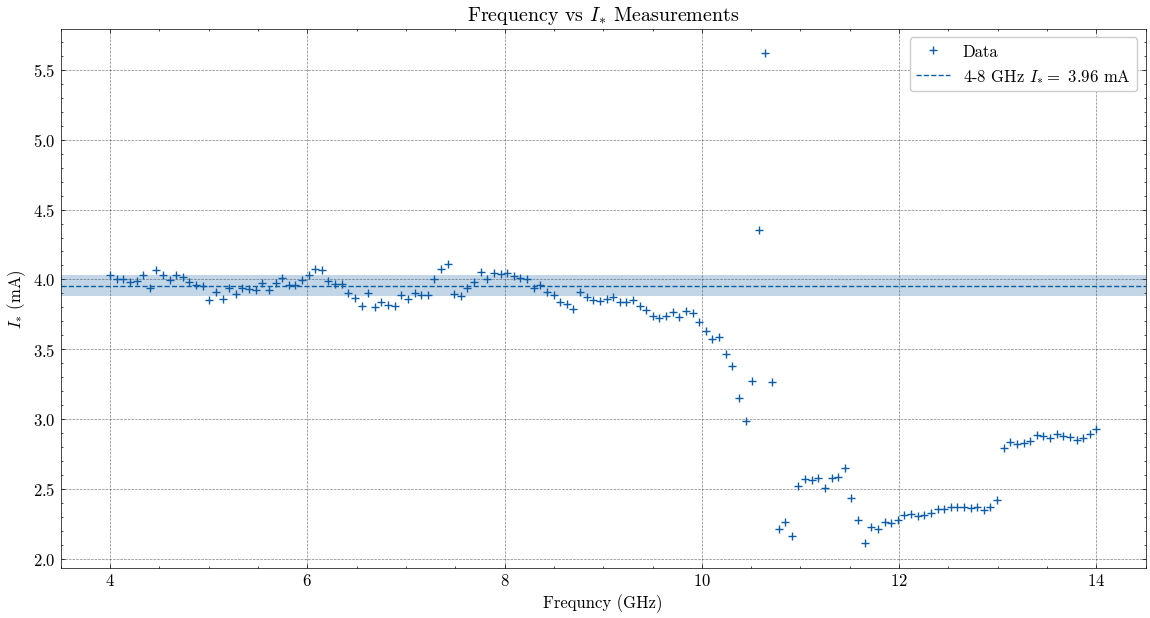

In [17]:
full_band_avg = np.mean(istars)
full_band_std = np.std(istars)

mask = np.where((istar_frequencies >= 4e9) & (istar_frequencies <= 8e9))
banded_avg = np.mean(istars[mask])
banded_std = np.std(istars[mask])

plt.plot(istar_frequencies/1e9, istars, '+', label='Data')
# plt.axhline(y=full_band_avg, linestyle='--', color='forestgreen', label='Full Band I*')
# plt.axhspan(full_band_avg - full_band_std, full_band_avg + full_band_std, alpha=0.15, color='forestgreen')
plt.axhline(y=banded_avg, linestyle='--', label='4-8 GHz ' + r'$I_{*}=$' + ' ' + str(round(banded_avg, 2)) + ' mA')
plt.axhspan(banded_avg - banded_std, banded_avg + banded_std, alpha=0.25)
plt.xlabel('Frequncy (GHz)')
plt.ylabel(r'$I_{*}$' + ' (mA)')
plt.title('Frequency vs ' + r'$I_{*}$' + ' Measurements')
plt.legend()
plt.savefig('IstarVsFreq.png', bbox_inches='tight')

In [ ]:
(3/2*np.sqrt(3))*3

np.float64(7.794228634059948)